# Exploratory Data Analysis

## Import Libraries

In [28]:
import boto3
import sagemaker
from pyathena import connect
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets

In [11]:
reviews_path = "s3://ads508-team1-sephora/curated/reviews/reviews.parquet"
products_path = "s3://ads508-team1-sephora/curated/products/products.parquet"

reviews = pd.read_parquet(reviews_path, engine="pyarrow")
products = pd.read_parquet(products_path, engine="pyarrow")

In [12]:
reviews.head()

,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,None,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,None,None,None,None,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,None,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,None,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [13]:
products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,None,None,None,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


## Histograms of Reviews Features

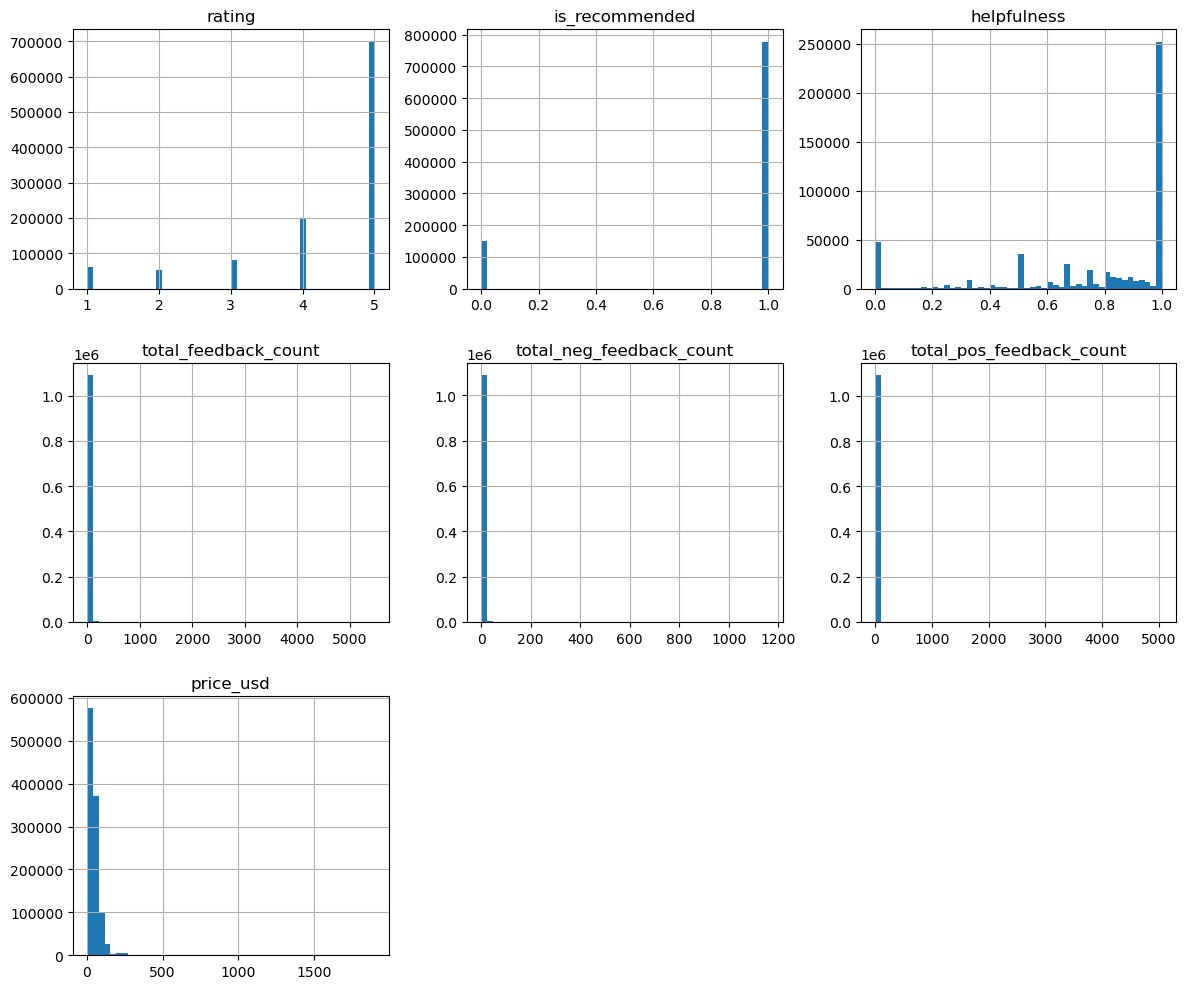

In [20]:
reviews.hist(figsize = (12, 10), bins = 50)
plt.tight_layout()
plt.show()

## Boxplot of Reviews Features

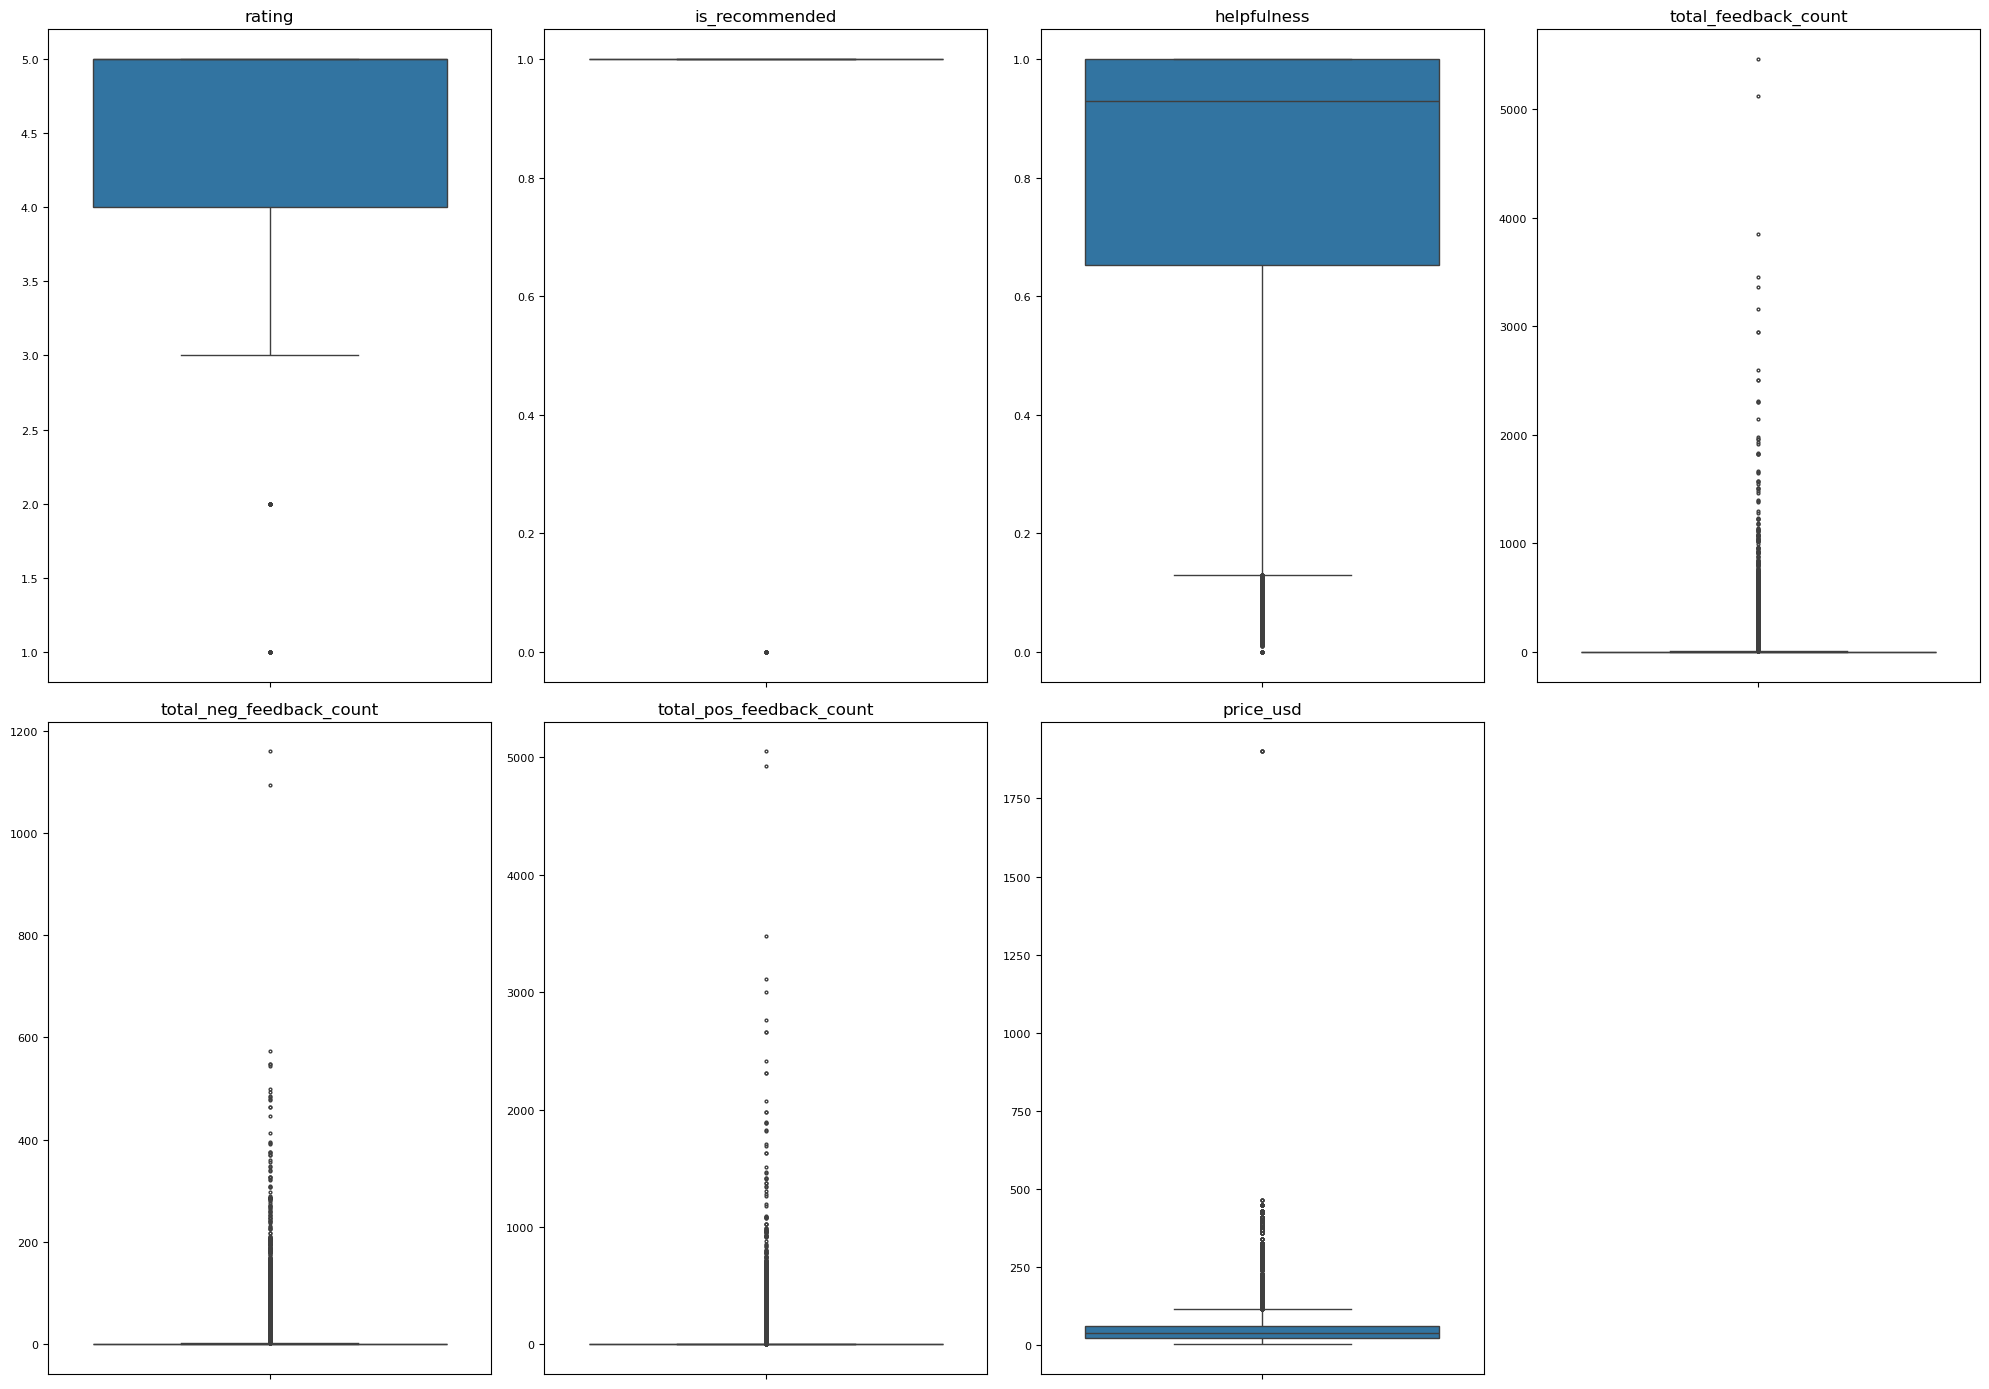

In [31]:
num_cols = reviews.select_dtypes(include=["int64", "float64"]).columns

# Grid setup
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=reviews[col], ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Histogram of Products Features

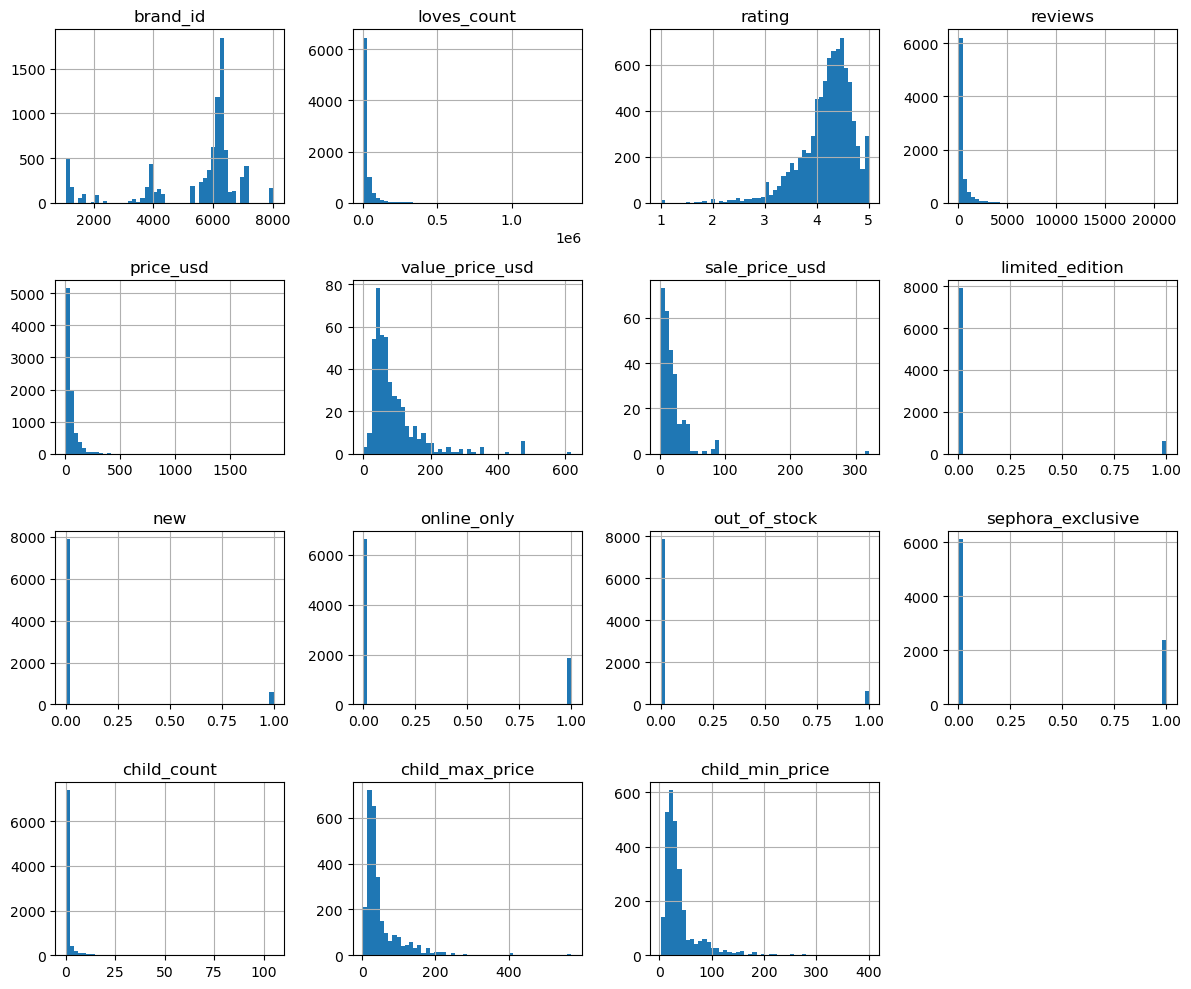

In [32]:
products.hist(figsize = (12, 10), bins = 50)
plt.tight_layout()
plt.show()

## Boxplot of Products Features

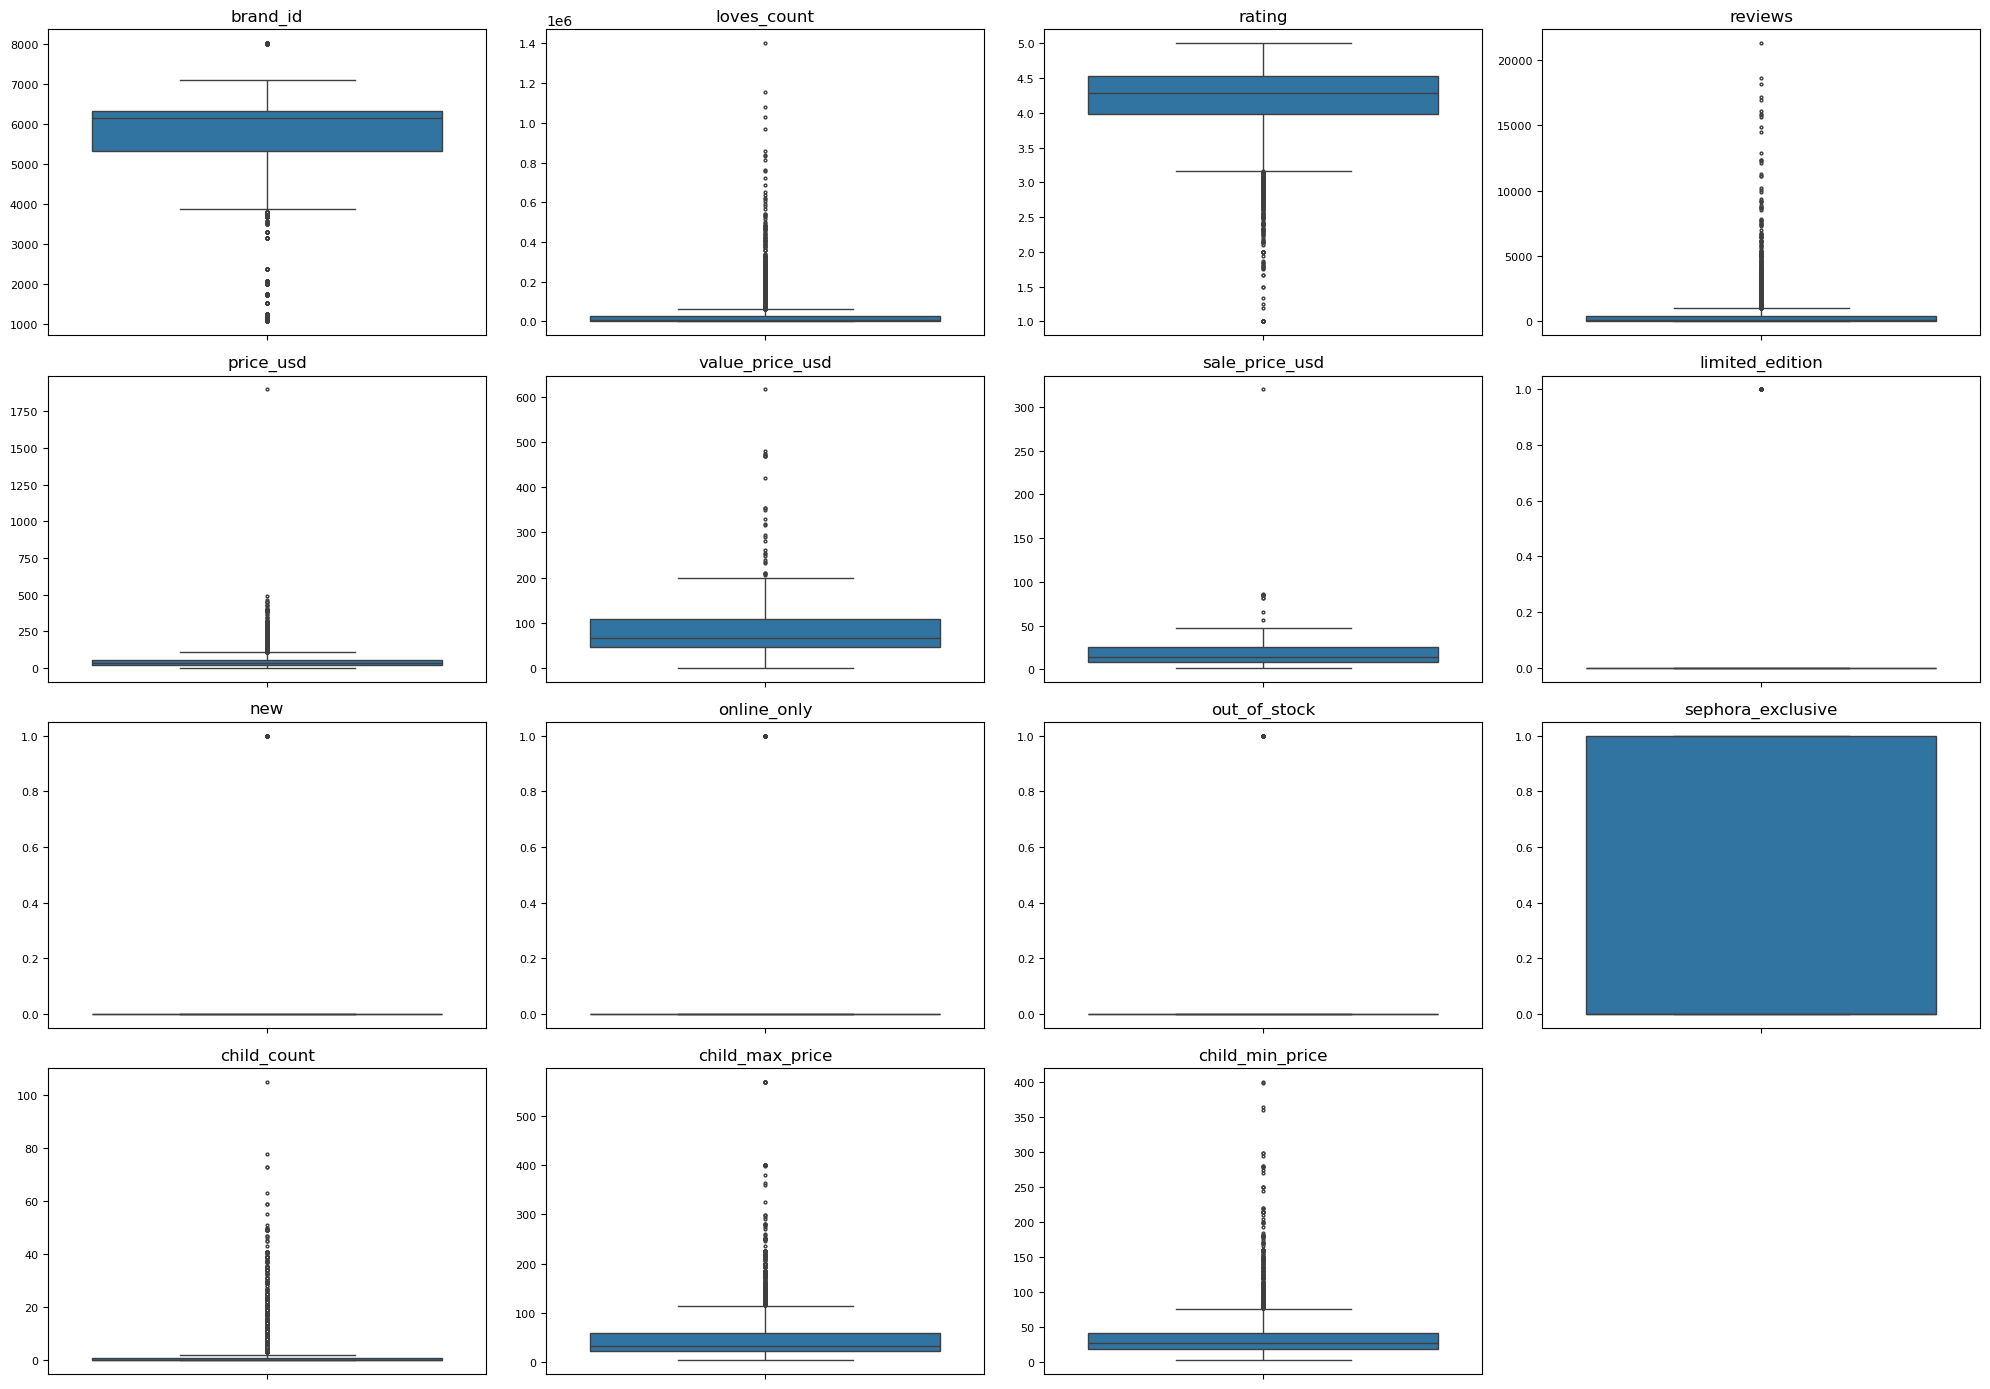

In [33]:
num_cols = products.select_dtypes(include=["int64", "float64"]).columns

# Grid setup
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=products[col], ax=axes[i], fliersize=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis="both", labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Reviews Heatmap

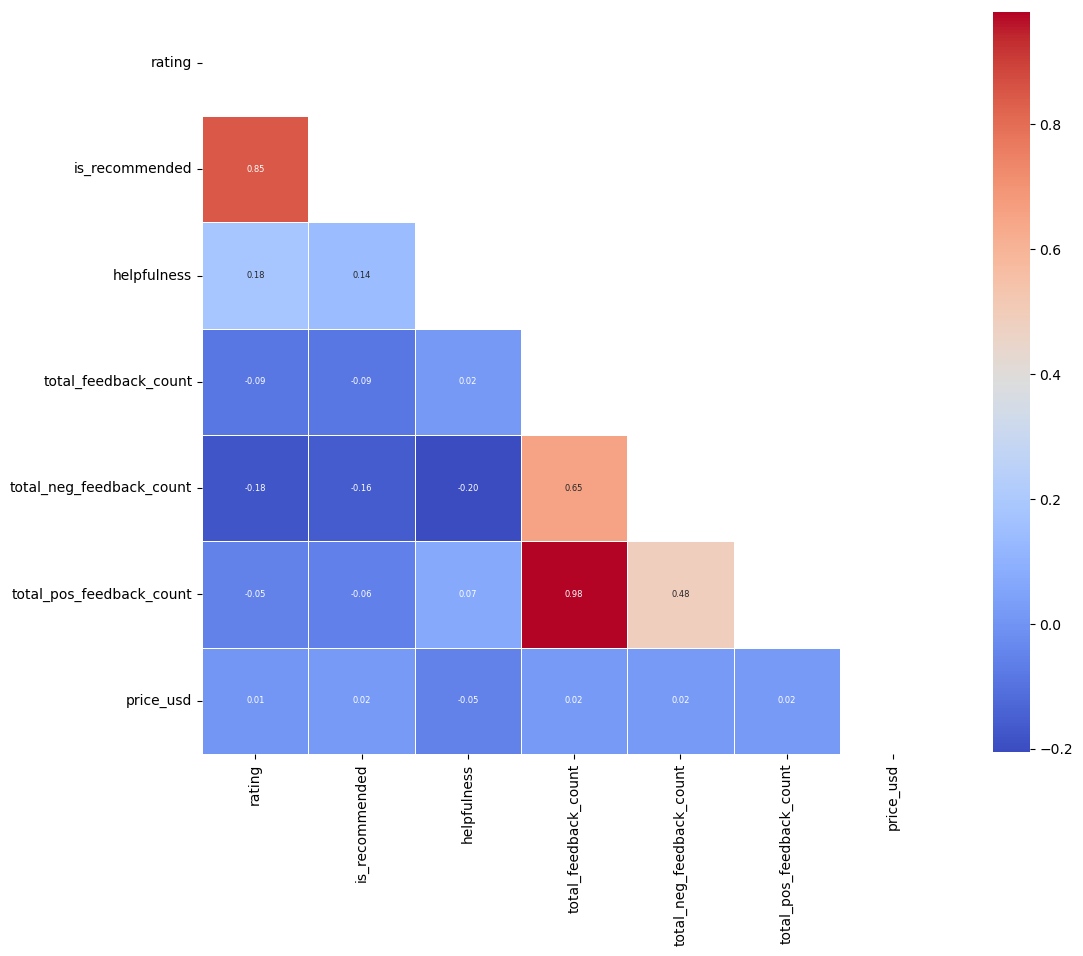

In [36]:
num_reviews = reviews.select_dtypes(include=["number"])

corr = num_reviews.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.show()

## Products Heatmap

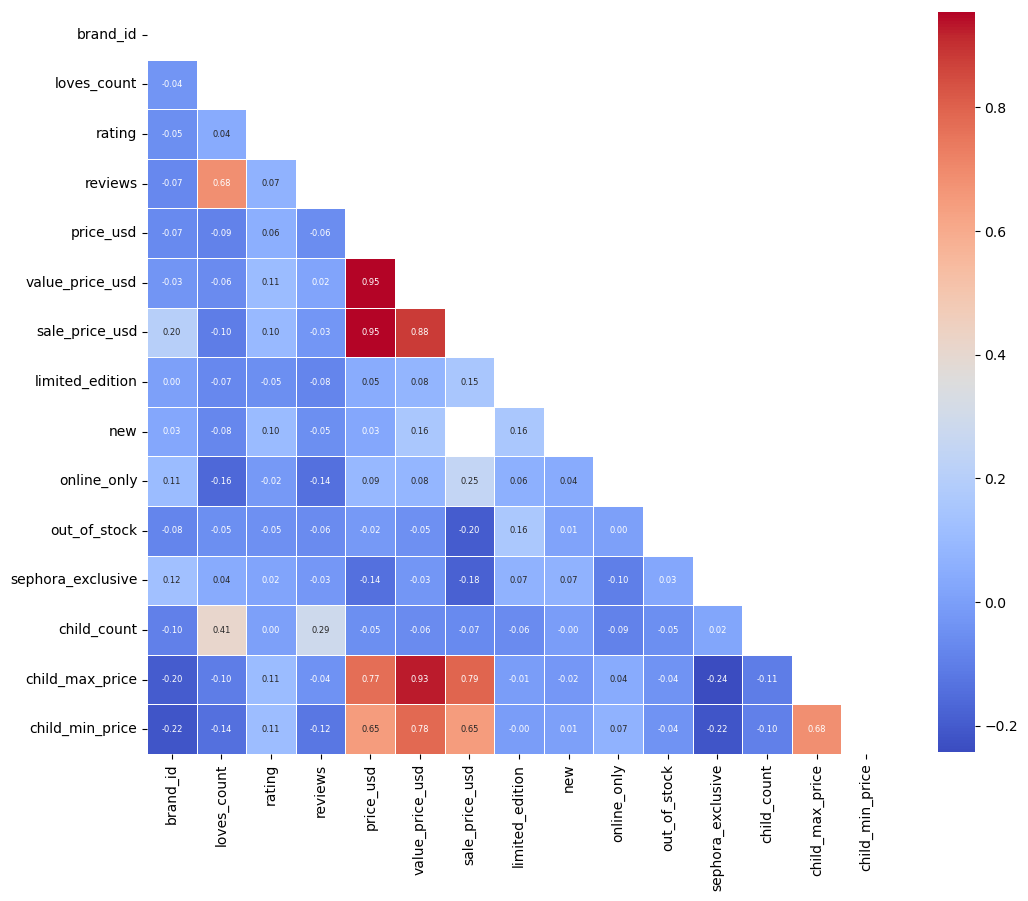

In [37]:
num_products = products.select_dtypes(include=["number"])

corr = num_products.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.show()

## Brand Distribution

In [51]:
reviews["brand_name"].nunique()

142

In [52]:
products["brand_name"].nunique()

304

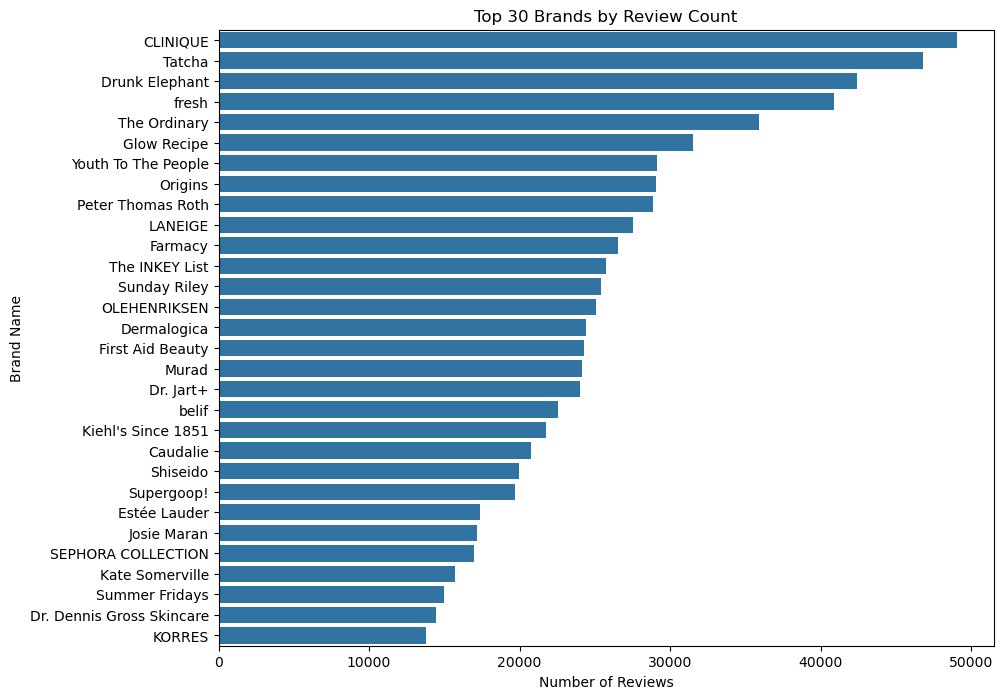

In [50]:
brand_counts = reviews["brand_name"].value_counts().head(30)

plt.figure(figsize=(10,8))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.xlabel("Number of Reviews")
plt.ylabel("Brand Name")
plt.title("Top 30 Brands by Review Count")
plt.show()

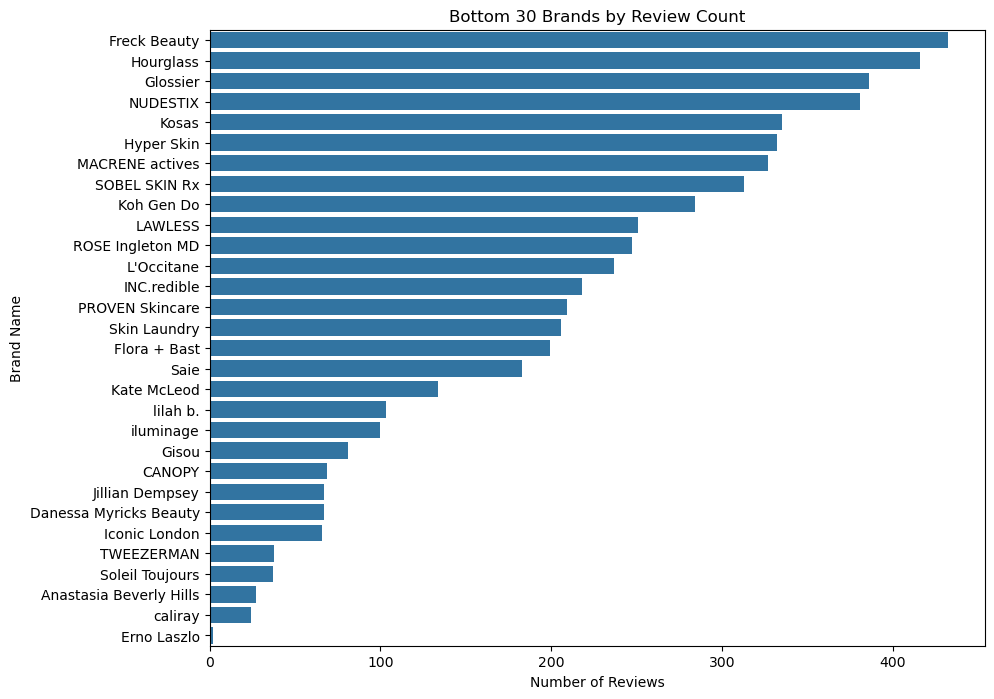

In [54]:
brand_counts = reviews["brand_name"].value_counts().sort_values().head(30).sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.xlabel("Number of Reviews")
plt.ylabel("Brand Name")
plt.title("Bottom 30 Brands by Review Count")
plt.show()

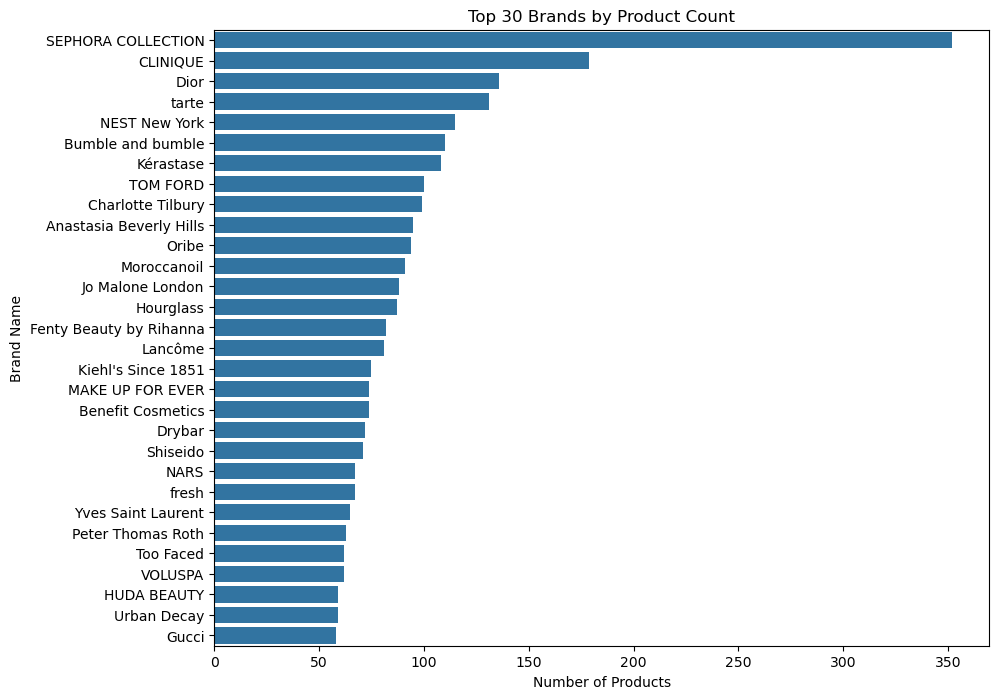

In [57]:
brand_counts = products["brand_name"].value_counts().head(30)

plt.figure(figsize=(10,8))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.xlabel("Number of Products")
plt.ylabel("Brand Name")
plt.title("Top 30 Brands by Product Count")
plt.show()

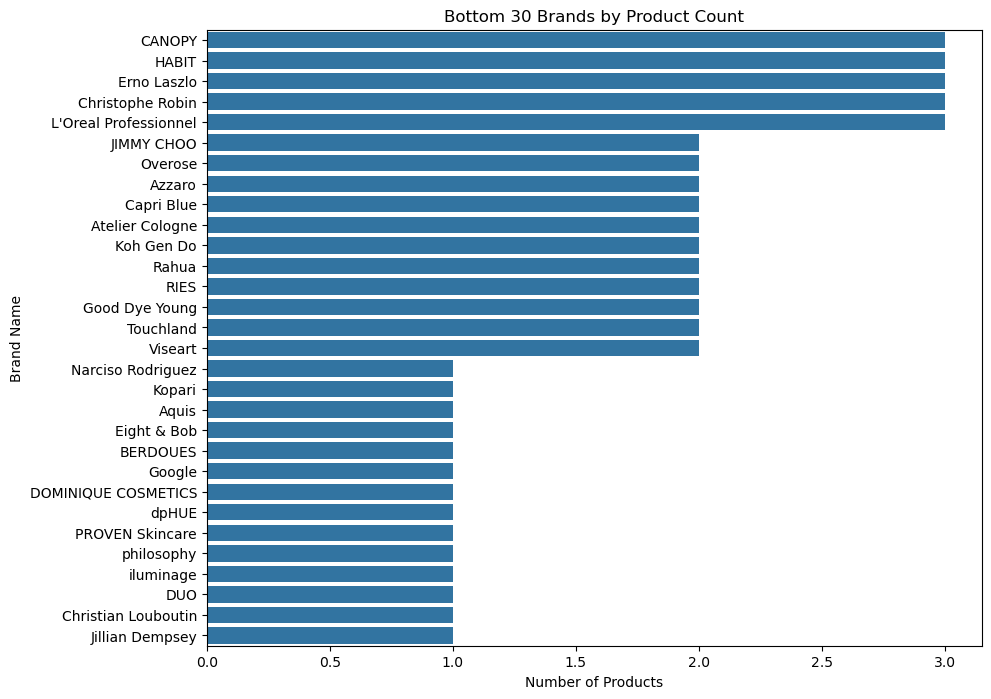

In [58]:
brand_counts = products["brand_name"].value_counts().sort_values().head(30).sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.xlabel("Number of Products")
plt.ylabel("Brand Name")
plt.title("Bottom 30 Brands by Product Count")
plt.show()

## Category

In [60]:
print("Primary Categories:")
print(products["primary_category"].unique())

print("\nSecondary Categories:")
print(products["secondary_category"].unique())

print("\nTertiary Categories:")
print(products["tertiary_category"].unique())

Primary Categories:
['Fragrance' 'Bath & Body' 'Mini Size' 'Hair' 'Makeup' 'Skincare'
 'Tools & Brushes' 'Men' 'Gifts']

Secondary Categories:
['Value & Gift Sets' 'Women' 'Body Moisturizers' 'Fragrance' 'Men'
 'Candles & Home Scents' 'Body Care' 'Hair Styling & Treatments'
 'Shampoo & Conditioner' 'Mini Size' 'Lip' 'Moisturizers' 'Treatments'
 'Eye Care' 'Lip Balms & Treatments' 'Sunscreen' 'Cleansers' 'Masks'
 'Skincare' 'Face' 'Eye' 'Cheek' 'Hair' 'Tools' 'Brushes & Applicators'
 'Makeup Palettes' 'Beauty Tools' 'Accessories' 'Makeup' 'Bath & Shower'
 'Wellness' 'High Tech Tools' 'Shop by Concern' None 'Self Tanners'
 'Shaving' 'Hair Tools' 'Nail' 'Beauty Accessories' 'Beauty Supplements'
 'Other Needs' 'Bath & Body']

Tertiary Categories:
['Perfume Gift Sets' 'Perfume' 'Rollerballs & Travel Size'
 'Body Lotions & Body Oils' None 'Cologne' 'Diffusers'
 'Deodorant & Antiperspirant' 'Candles' 'Hair Masks'
 'Leave-In Conditioner' 'Shampoo' 'Hair Oil' 'Hair Styling Products'
 'Scalp Tre

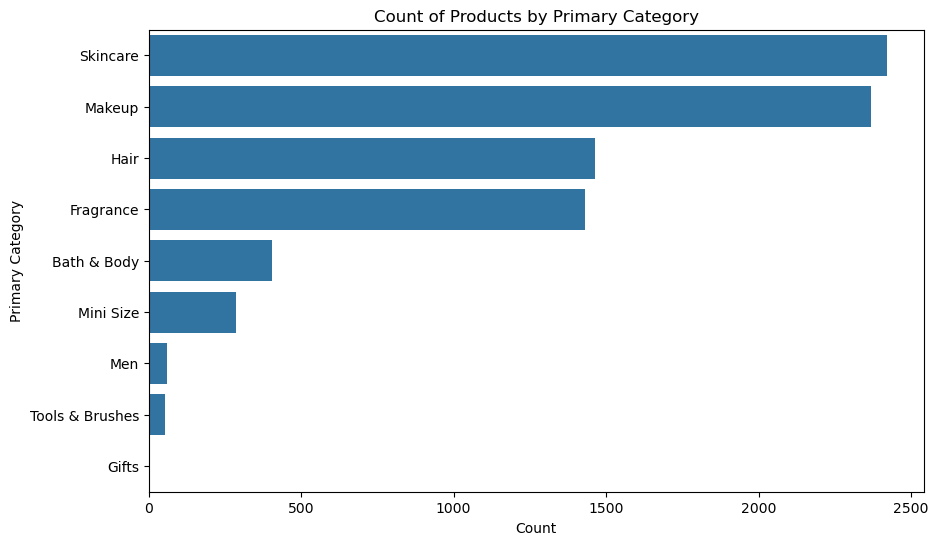

In [62]:
category_counts = products["primary_category"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.xlabel("Count")
plt.ylabel("Primary Category")
plt.title("Count of Products by Primary Category")

plt.show()

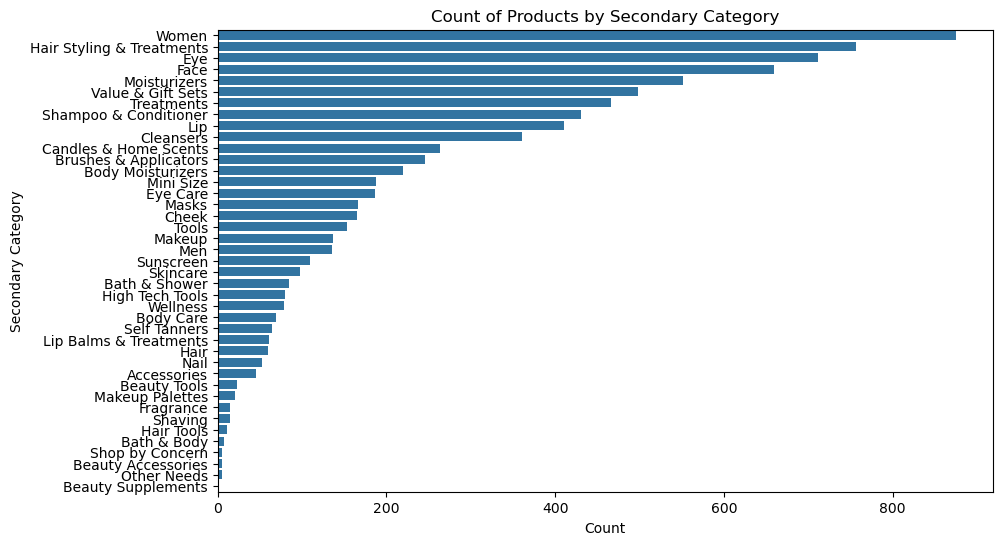

In [63]:
category_counts = products["secondary_category"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.xlabel("Count")
plt.ylabel("Secondary Category")
plt.title("Count of Products by Secondary Category")

plt.show()

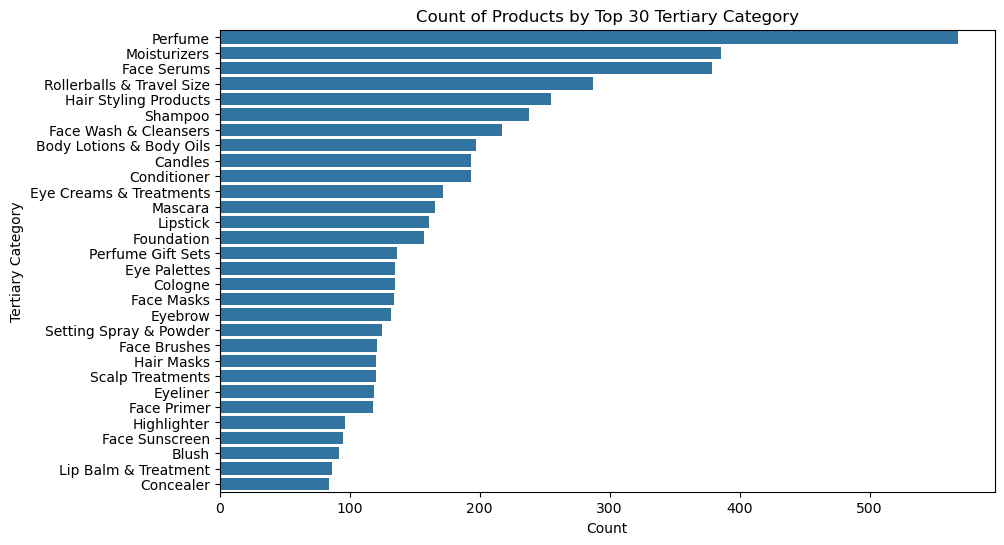

In [66]:
category_counts = products["tertiary_category"].value_counts().head(30)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.xlabel("Count")
plt.ylabel("Tertiary Category")
plt.title("Count of Products by Top 30 Tertiary Category")

plt.show()

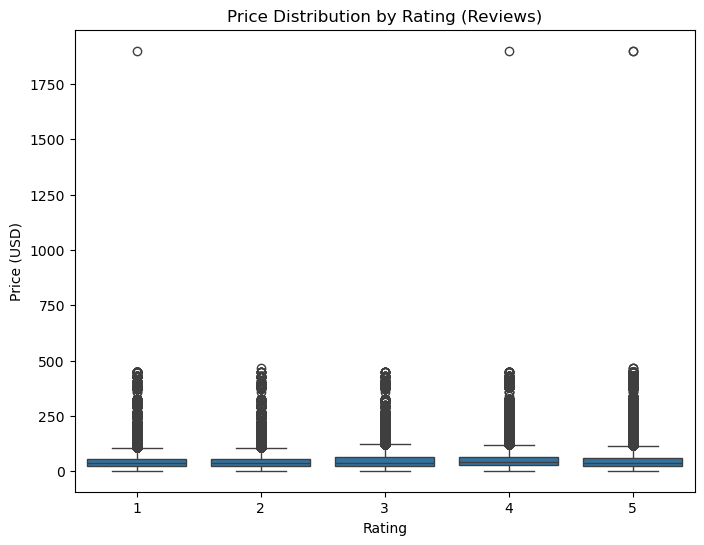

In [73]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=reviews,
    x="rating",
    y="price_usd"
)

plt.xlabel("Rating")
plt.ylabel("Price (USD)")
plt.title("Price Distribution by Rating (Reviews)")

plt.show()

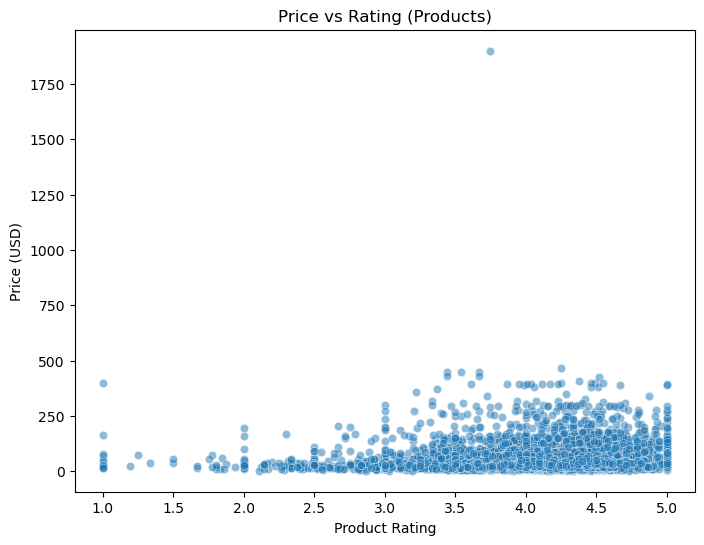

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=products,
    x="rating",
    y="price_usd",
    alpha=0.5
)

plt.xlabel("Product Rating")
plt.ylabel("Price (USD)")
plt.title("Price vs Rating (Products)")

plt.show()

## Helpfulness Analysis

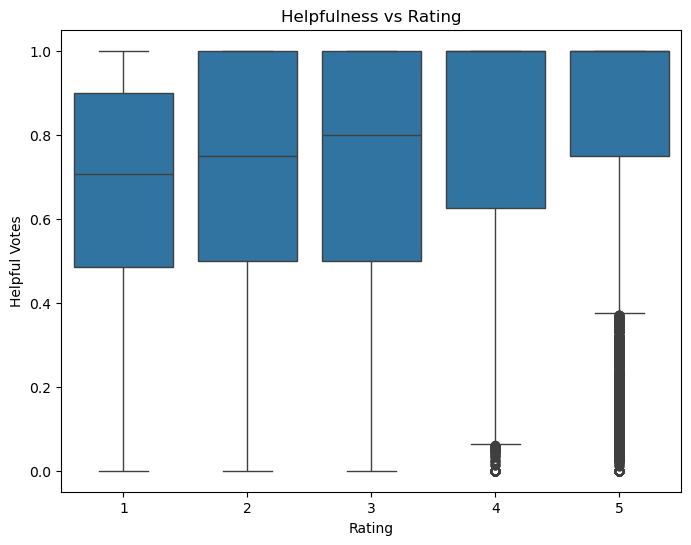

In [81]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=reviews,
    x="rating",
    y="helpfulness"
)

plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.title("Helpfulness vs Rating")

plt.show()

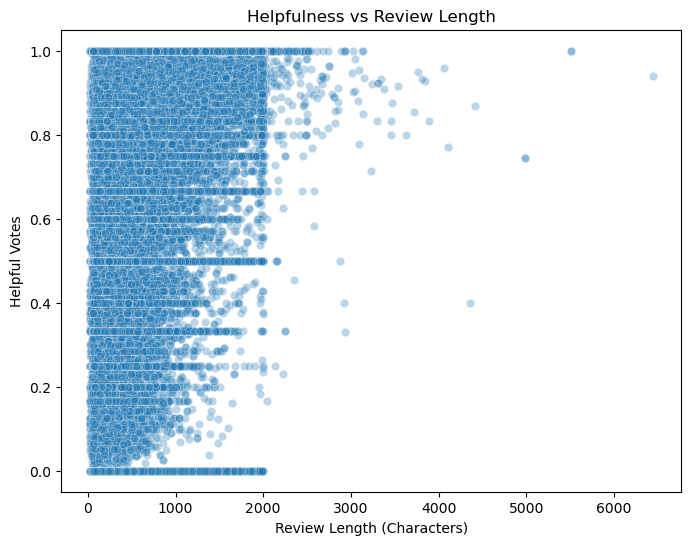

In [82]:
reviews["review_length"] = reviews["review_text"].str.len()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=reviews,
    x="review_length",
    y="helpfulness",
    alpha=0.3
)

plt.xlabel("Review Length (Characters)")
plt.ylabel("Helpful Votes")
plt.title("Helpfulness vs Review Length")

plt.show()

In [86]:
pd.set_option("display.max_colwidth", None)

reviews.sort_values("helpfulness", ascending=False)[
    ["brand_name","rating","helpfulness","review_text"]
].head(20)

,brand_name,rating,helpfulness,review_text
37,LANEIGE,5,1.0,"I am super impressed with this lip mask. I use it at bedtime and wake up with soft lips! ( I struggle with cracked and peeling lips every winter ) I also use it on top of my lip liner in the morning for a plumped, soft look."
1094377,Jack Black,5,1.0,"Have used this lotion for two weeks now, skin feels really good, ultra moisturized. Easily one of the best lotions on the market. You get what you pay for. This will be a staple in my routine from now on."
0,NUDESTIX,5,1.0,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!"
5,LANEIGE,4,1.0,"The scent isn’t my favourite but it works great! I put it on every night before I go to sleep and every morning I wake up with smooth, moisturizer and soft. Packaging is amazing as well"
1094376,Estée Lauder,5,1.0,Really good for dry patchy skin!!! My skin has been very dry lately and this wash is perfect you only need a little it gets very foamy after adding water!!!
8,LANEIGE,5,1.0,"I love this stuff. I first had the sample size from a Sephora Birthday gift, and once I had run through it I knew it was a purchase. I live in an incredibly dry environment, great for macarons, but terrible for my skin. This lip mask helps to keep my lips from becoming too chapped."
9,LANEIGE,5,1.0,"I purchased the Sweet Candy scent at my local Sephora and I am OBSESSED!! I will be honest, the scent is a bit strong - but they’re all strongly scented. My lips are so soft. 10/10!"
1094361,Hourglass,5,1.0,Bought the travel size to test if I liked it. Immediately went and bought the full size. Love how much this lathers and the slight fragrance is nice. Leaves my skin feeling extremely cleansed.
1094364,Sulwhasoo,4,1.0,This is a nice light daytime moisturizer for the summer
1094367,Drunk Elephant,5,1.0,I love that you have to mix the two items for the vitamin C


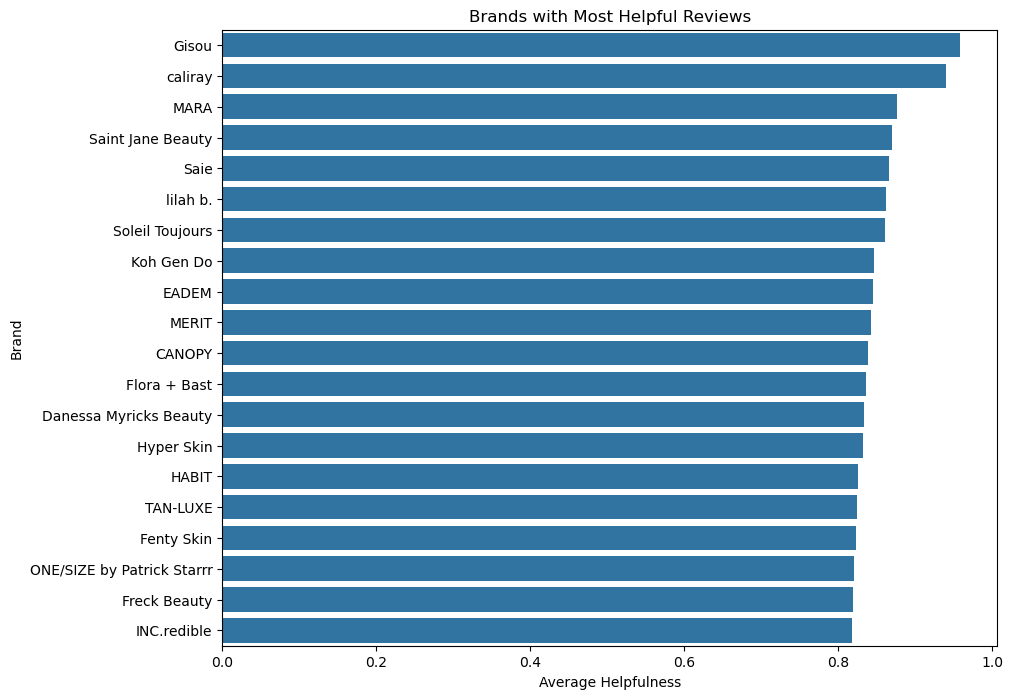

In [85]:
brand_helpfulness = reviews.groupby("brand_name")["helpfulness"].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    x=brand_helpfulness.values,
    y=brand_helpfulness.index
)

plt.xlabel("Average Helpfulness")
plt.ylabel("Brand")
plt.title("Brands with Most Helpful Reviews")

plt.show()

## Love Count Analysis

In [92]:
products.sort_values("loves_count", ascending=False)[
    ["product_name","brand_name","loves_count","rating","price_usd"]
].head(20)

,product_name,brand_name,loves_count,rating,price_usd
6242,Soft Pinch Liquid Blush,Rare Beauty by Selena Gomez,1401068,4.5356,23.0
5249,Radiant Creamy Concealer,NARS,1153594,4.3080,32.0
4431,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,1081315,4.3508,24.0
6434,Cream Lip Stain Liquid Lipstick,SEPHORA COLLECTION,1029051,4.3201,15.0
2523,Gloss Bomb Universal Lip Luminizer,Fenty Beauty by Rihanna,968317,4.6357,21.0
2524,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,856497,4.0356,40.0
5250,Blush,NARS,840076,4.6643,32.0
247,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,834189,4.4056,25.0
4458,Translucent Loose Setting Powder,Laura Mercier,813497,4.5029,43.0
7648,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,763168,4.2439,6.0


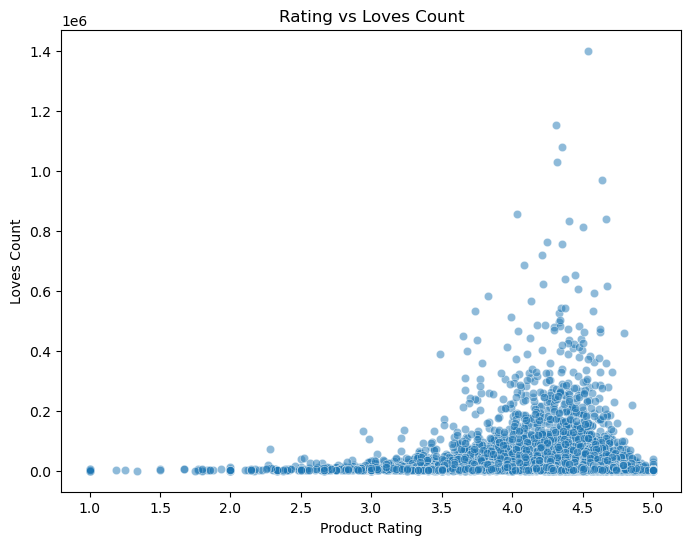

In [93]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=products,
    x="rating",
    y="loves_count",
    alpha=0.5
)

plt.xlabel("Product Rating")
plt.ylabel("Loves Count")
plt.title("Rating vs Loves Count")

plt.show()

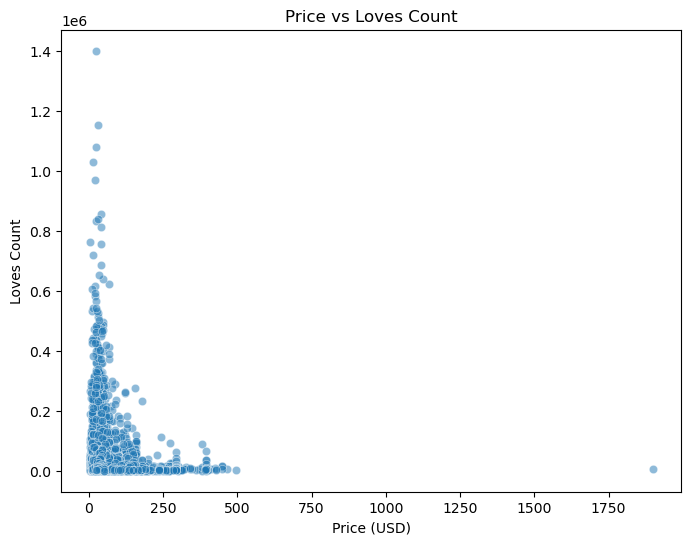

In [94]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=products,
    x="price_usd",
    y="loves_count",
    alpha=0.5
)

plt.xlabel("Price (USD)")
plt.ylabel("Loves Count")
plt.title("Price vs Loves Count")

plt.show()

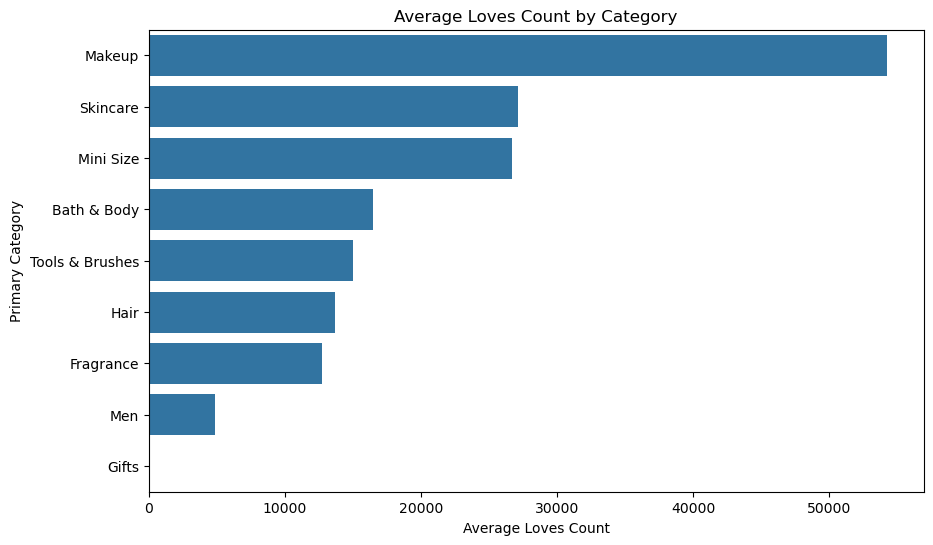

In [96]:
category_love = products.groupby("primary_category")["loves_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_love.values,
    y=category_love.index
)

plt.xlabel("Average Loves Count")
plt.ylabel("Primary Category")
plt.title("Average Loves Count by Category")

plt.show()

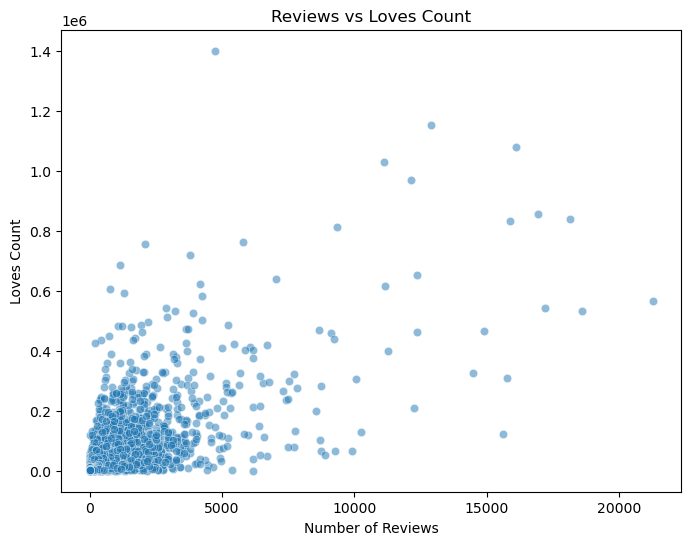

In [97]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=products,
    x="reviews",
    y="loves_count",
    alpha=0.5
)

plt.xlabel("Number of Reviews")
plt.ylabel("Loves Count")
plt.title("Reviews vs Loves Count")

plt.show()